____
# Sea state dependency


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import (
    dataset_coloc_combs,
    DRIFTER,
    ALTI,
    WD,
    compute_mean_square,
    compute_mean_square_groupby,
    plot_error,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2501000', 'swot2502000', 'swot2503000', 'swot2504000', 'swot2505000', 'swot2506000', 'swot2507000', 'swot2508000', 'swot2509000', 'swot25010000', 'swot25011000', 'swot25012000', 'swot25013000', 'swot25014000', 'swot2kmnaive', 'swot2km1000', 'swot2km2000', 'swot2km3000', 'swot2km4000', 'swot2km5000', 'swot2km6000', 'swot2km7000', 'swot2km8000', 'swot2km9000', 'swot2km10000', 'swot2km11000', 'swot2km12000', 'swot2km13000', 'swot2km14000', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [3]:
comb_list = [
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        spectral_key="",
        wd_key="era5",
        ggd_var="etac",
        wd_depth="0",
        wd_model="rio",
    ),
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        spectral_key="",
        wd_key="era5",
        ggd_var="etac",
        wd_depth="15",
        wd_model="rio",
    ),
]

DS = dataset_coloc_combs(comb_list, nearest=False)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < 12).dropna("row_number")

DSS = DS.where(DS.depth == 0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth == 15, drop=True).isel(id_comb=[1])

nofilter___swot2kmnaive_etac__rio_0era5
nofilter___swot2kmnaive_etac__rio_15era5
Identified SWOT and drifter outliers have been removed


In [4]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi) * e - np.sin(phi) * n, np.sin(phi) * e + np.cos(phi) * n


def crossalg_proj(dsen):
    ds = dsen.copy()
    ds["sumx"], ds["sumy"] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[["sumx", "sumy"]]
    var = ["acc", "cor", "ggd", "wd", "sum"]
    prod = [l for l in ds.keys() if "prodn" in l]
    exc = [l for l in ds.keys() if "excn" in l]
    for v in var:
        dsxy[v + "x"], dsxy[v + "y"] = rotate(dsen[v + "e"], dsen[v + "n"], dsen.phi)

    for direction in ["x", "y"]:
        if direction == "x":
            l = {"acc": "accx", "cor": "corx", "ggd": "ggdx", "wd": "wdx"}
        if direction == "y":
            l = {"acc": "accy", "cor": "cory", "ggd": "ggdy", "wd": "wdy"}

        # sum
        dsxy["sum" + direction] = sum([dsxy[l[v]] for v in l])

        # simple var + sum- one term
        for v in l:
            dsxy[l[v]] = dsxy[l[v]]
            dsxy["exc" + direction + "_" + v] = dsxy["sum" + direction] - dsxy[l[v]]

        # 2 by 2 product
        import itertools

        couple = list(itertools.combinations(list(l.keys()), 2))
        for c in couple:
            dsxy["prod" + direction + "_" + "_".join(c)] = (
                dsxy[c[0] + direction] * dsxy[c[1] + direction]
            )
    return dsxy


DSr = crossalg_proj(DS)

DSSr = DSr.where(DSr.depth == 0, drop=True).isel(id_comb=[0])
DSDr = DSr.where(DSr.depth == 15, drop=True).isel(id_comb=[1])

In [5]:
DSr = xr.concat([DSSr.isel(id_comb=0), DSDr.isel(id_comb=0)], dim="row_number")

In [6]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(
        data=nsamples,
        dims=[y, x],
        coords={x: ([x], (xx[:-1] + xx[1:]) / 2), y: ([y], (yy[:-1] + yy[1:]) / 2)},
    )

    fig = plt.figure(figsize=(9, 4))

    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )

    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

    da.plot(ax=ax, add_colorbar=False)
    # da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    # ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )

    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title("")
    ax_histx.set_title("")
    ax_histy.set_xlabel("")
    ax_histx.set_xlabel("")
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/2637845017.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/2910541907.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


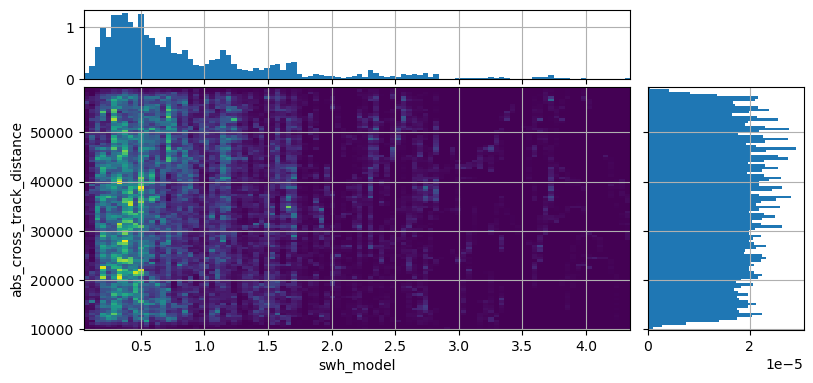

In [7]:
dfr = DSr.to_dataframe().reset_index().set_index("row_number")
dfs = pd.read_csv(ALTI["swot2kmnaive"]).set_index("row_number")
dfs["abs_cross_track_distance"] = abs(dfs["cross_track_distance"])

dfrr = pd.concat(
    [
        dfs[
            [
                "swh_model",
                "abs_cross_track_distance",
                "ssh_karin_uncert",
                "distance_to_coast",
            ]
        ],
        dfr,
    ],
    axis=1,
).dropna()

dss = dfrr.to_xarray()
plot_join_pdfs(dss, "swh_model", "abs_cross_track_distance", binx=100, biny=100)

In [154]:
DSr

<xarray.Dataset> Size: 133MB
Dimensions:        (row_number: 272855)
Coordinates:
    datetime       (row_number) datetime64[ns] 2MB 2023-04-01T11:50:00 ... 20...
    longitude      (row_number) float64 2MB 5.538 5.539 5.54 ... 2.415 2.414
    latitude       (row_number) float64 2MB 42.31 42.31 42.31 ... 39.79 39.79
    pass_number    (row_number) int64 2MB 3 3 3 3 3 3 3 ... 16 16 16 16 16 16 16
    time_to_swot   (row_number) timedelta64[ns] 2MB 11:52:32.696536 ... 11:53...
    cycle_number   (row_number) int64 2MB 478 478 478 478 ... 577 577 577 577
    drifter_id     (row_number) object 2MB '0-4351296' ... '300534060015760'
    drifter_type   (row_number) object 2MB 'CARTHE' 'CARTHE' ... 'SVP' 'SVP'
    depth          (row_number) int64 2MB 0 0 0 0 0 0 0 ... 15 15 15 15 15 15 15
    phi            (row_number) float64 2MB 0.2477 0.2478 0.2478 ... 2.917 2.917
  * row_number     (row_number) int64 2MB 144 145 146 ... 376720 376721 376722
    id_comb        (row_number) <U40 44MB 'nofilter___swot2kmnaive_etac__rio_...
Data variables: (12/30)
    sumx           (row_number) float64 2MB -2.019e-05 -2.019e-05 ... -2.707e-07
    sumy           (row_number) float64 2MB -1.835e-06 -5.437e-07 ... 3.404e-05
    accx           (row_number) float64 2MB -8.189e-06 -9.057e-06 ... 1.323e-07
    accy           (row_number) float64 2MB 1.401e-07 7.55e-07 ... -8.368e-06
    corx           (row_number) float64 2MB 8.297e-06 8.27e-06 ... 1.283e-05
    cory           (row_number) float64 2MB 1.721e-05 1.671e-05 ... 1.017e-05
    ...             ...
    prody_acc_cor  (row_number) float64 2MB 2.412e-12 1.261e-11 ... -8.512e-11
    prody_acc_ggd  (row_number) float64 2MB 4.665e-14 9.385e-13 ... -2.797e-10
    prody_acc_wd   (row_number) float64 2MB -2.735e-12 -1.453e-11 ... 9.951e-12
    prody_cor_ggd  (row_number) float64 2MB 5.732e-12 2.077e-11 ... 3.4e-10
    prody_cor_wd   (row_number) float64 2MB -3.361e-10 -3.216e-10 ... -1.21e-11
    prody_ggd_wd   (row_number) float64 2MB -6.5e-12 -2.392e-11 ... -3.975e-11

_________
# Regular bins

In [33]:
compute_error = "centrallimit"

dfswh = dfrr[
    (dfrr.abs_cross_track_distance > 20e3) & (dfrr.abs_cross_track_distance < 50e3)
]
swh_dist_bins = np.linspace(0, 4, 10)
dfswh["swh_model_cut"] = pd.cut(
    dfswh["swh_model"],
    swh_dist_bins,
    labels=(swh_dist_bins[1:] + swh_dist_bins[:-1]) / 2,
)
dsswh = compute_mean_square_groupby(
    dfswh,
    groupby="swh_model_cut",
    dirname=("x", "y"),
    compute_error=compute_error,
    vars_errors=["Ex_ggd", "Ey_ggd"],
)
dsswh["meanbin_abs_cross_track_distance"] = (
    dfswh.groupby("swh_model_cut", observed=False)
    .abs_cross_track_distance.mean()
    .dropna()
    .to_xarray()
)
dsswh = dsswh.where(dsswh.nb_coloc > 0).dropna("swh_model_cut")

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/1795422111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/1813606424.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGDxu'] = dfswh.ggdx**2/U2
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/1813606424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['GGDyu'] = dfswh.ggdy**2/U2
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/1813606424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

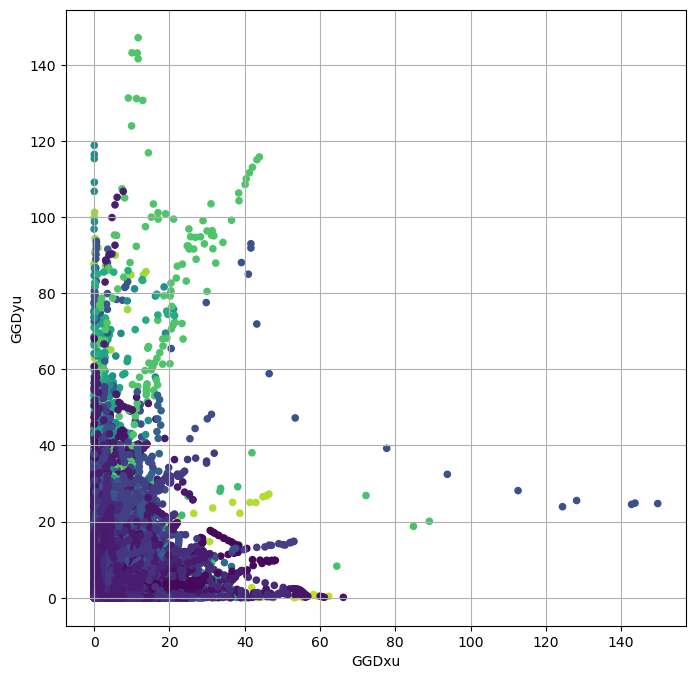

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dfswh["GGDxu"] = dfswh.ggdx**2 / U2
dfswh["GGDyu"] = dfswh.ggdy**2 / U2
dfswh["GGD"] = dfswh.GGDxu + dfswh.GGDyu
dfswh.plot.scatter("GGDxu", "GGDyu", c=dfswh.swh_model, ax=ax)
ax.grid()

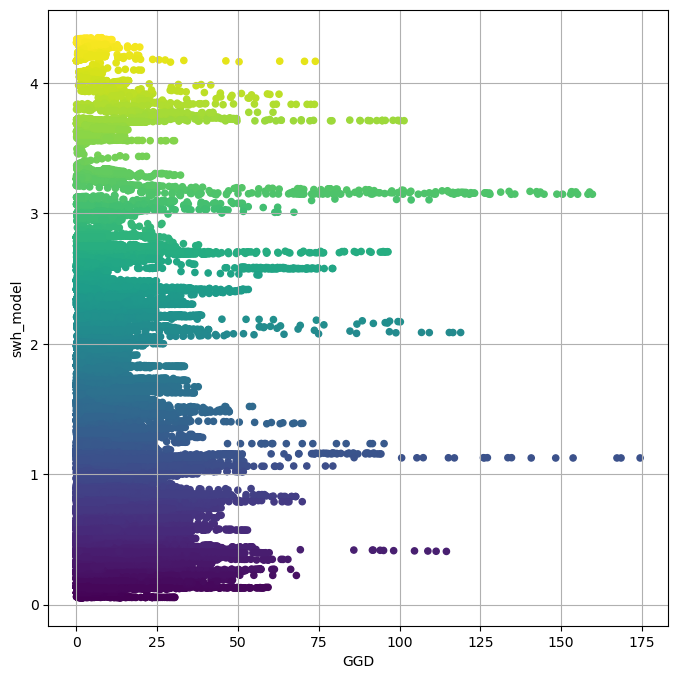

In [157]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dfswh.plot.scatter("GGD", "swh_model", c=dfswh.swh_model, ax=ax)
ax.grid()

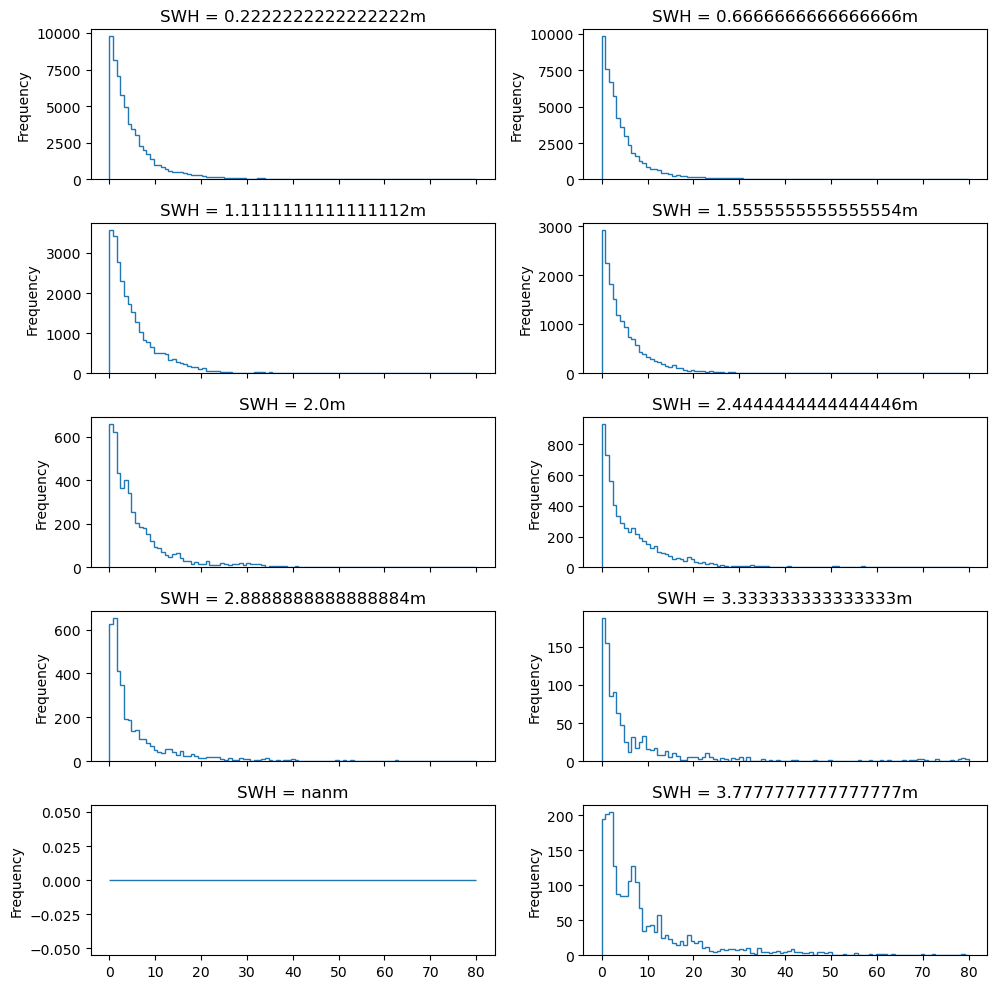

In [17]:
fig, axs = plt.subplots(5, 2, figsize=(10, 10), frameon=False, sharex=True)
axs = axs.flatten()
i = 0
for swh in sorted(dfswh.swh_model_cut.unique()):
    ax = axs[i]
    df_ = dfswh[dfswh.swh_model_cut == swh]
    df_.GGD.plot.hist(bins=np.linspace(0, 80, 100), histtype="step", ax=ax)
    ax.set_title(f"SWH = {swh}m")
    i += 1

fig.tight_layout()
# dfswh.groupby('swh_model_cut').GGD.plot.hist(bins = np.linspace(0,80,100), histtype='step', subplots=False)

<GeoAxes: xlabel='longitude', ylabel='latitude'>

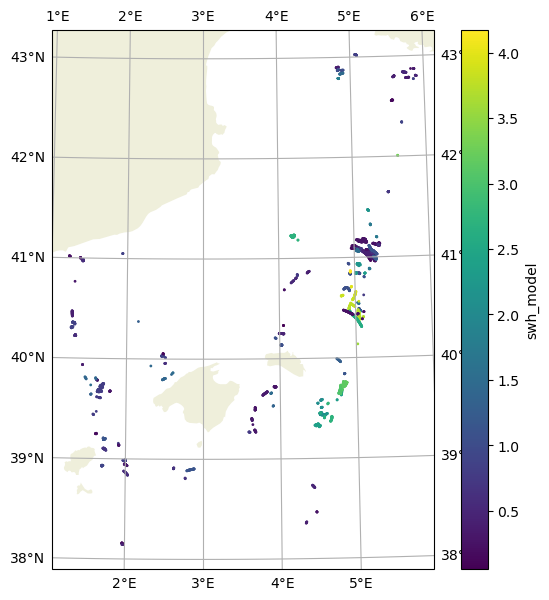

In [18]:
fig = plt.figure(figsize=(7, 7), frameon=False)
ax = fig.add_subplot(111, projection=ccrs.Orthographic(3, 40.5))
ax.add_feature(
    cfeature.LAND,
)
gl = ax.gridlines(
    draw_labels=True,
)

dfswh[dfswh.GGD > 30].plot.scatter(
    "longitude", "latitude", c="swh_model", ax=ax, transform=crs, s=1
)

(0.0, 4.0)

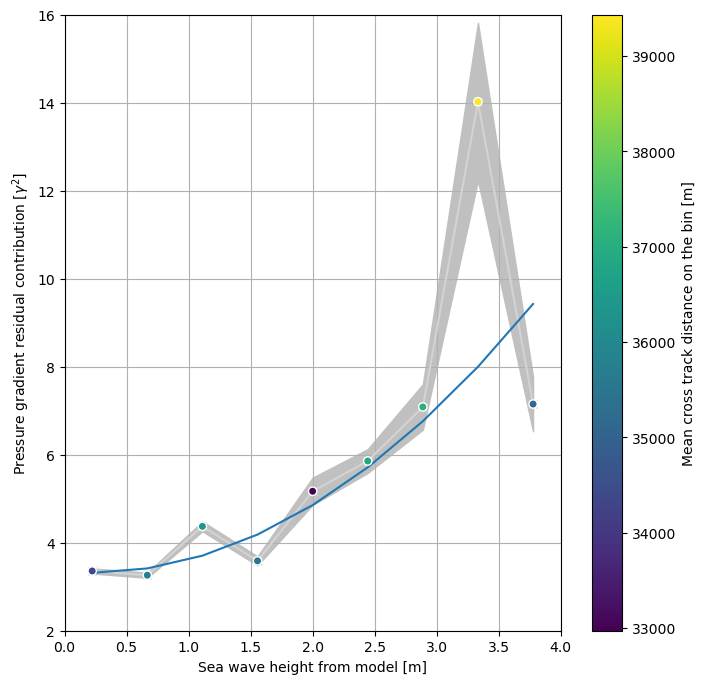

In [34]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dsswh["E_ggd"] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh["ser__E_ggd"] = dsswh.ser__Ex_ggd + dsswh.ser__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker="x", c="lightgrey")
plot_error(dsswh, "swh_model_cut", "E_ggd", ax=ax, suf="ser__")
sc = dsswh.plot.scatter(
    x="swh_model_cut", y="E_ggd", c=dsswh.meanbin_abs_cross_track_distance, zorder=10
)
plt.colorbar(sc, label="Mean cross track distance on the bin [m]")

c = dsswh.where(dsswh.swh_model_cut < 2).swh_model_cut
coef = np.polyfit(c, dsswh.E_ggd, 2, w=dsswh.nb_coloc)
ax.plot(c, coef[0] * c**2 + coef[1] * c + coef[2])


ax.grid()
ax.set_ylabel(r"Pressure gradient residual contribution [$\gamma^2$]")
ax.set_xlabel(r"Sea wave height from model [m]")
ax.set_ylim(2, 16)
ax.set_xlim(0, 4)

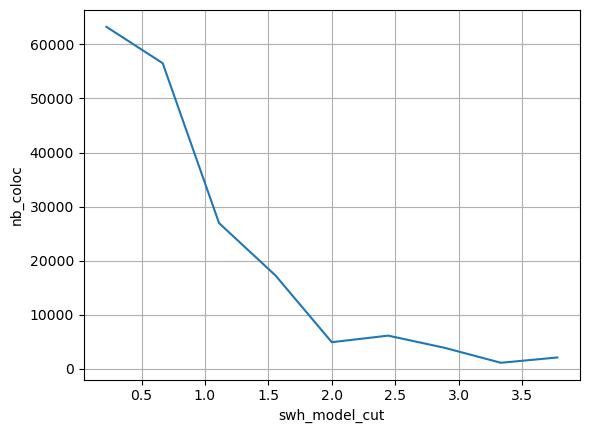

In [20]:
dsswh.nb_coloc.plot()
plt.grid()

Text(0.5, 0, 'Sea wave height from model [m]')

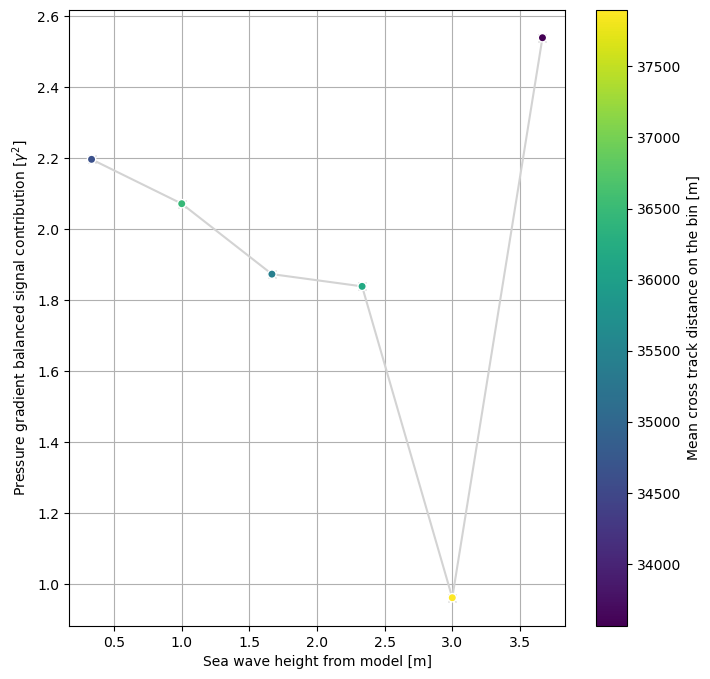

In [142]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dsswh["B_ggd"] = dsswh.Bx_ggd + dsswh.By_ggd
# dsswh['ber__B_ggd'] = dsswh.ber__Bx_ggd + dsswh.ber__By_ggd
dsswh.B_ggd.plot(ax=ax, marker="x", c="lightgrey")
# plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(
    x="swh_model_cut", y="B_ggd", c=dsswh.meanbin_abs_cross_track_distance, zorder=10
)
plt.colorbar(sc, label="Mean cross track distance on the bin [m]")


ax.grid()
ax.set_ylabel(r"Pressure gradient balanced signal contribution [$\gamma^2$]")
ax.set_xlabel(r"Sea wave height from model [m]")

# Same-nb bins

In [36]:
compute_error = "centrallimit"
n = 25
dfswh = dfrr[
    (dfrr.abs_cross_track_distance > 20e3) & (dfrr.abs_cross_track_distance < 50e3)
]
swh_dist_bins = np.array([float(dfswh.swh_model.quantile(i / n)) for i in range(n + 1)])
dfswh["swh_model_cut"] = pd.cut(
    dfswh["swh_model"],
    swh_dist_bins,
    labels=(swh_dist_bins[1:] + swh_dist_bins[:-1]) / 2,
)
dsswh = compute_mean_square_groupby(
    dfswh,
    groupby="swh_model_cut",
    dirname=("x", "y"),
    compute_error=compute_error,
    vars_errors=["Ex_ggd", "Ey_ggd"],
)
dsswh["meanbin_abs_cross_track_distance"] = (
    dfswh.groupby("swh_model_cut", observed=False)
    .abs_cross_track_distance.mean()
    .dropna()
    .to_xarray()
)
dsswh = dsswh.where(dsswh.nb_coloc > 0).dropna("swh_model_cut")

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_16018/206469896.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)


(0.0, 4.0)

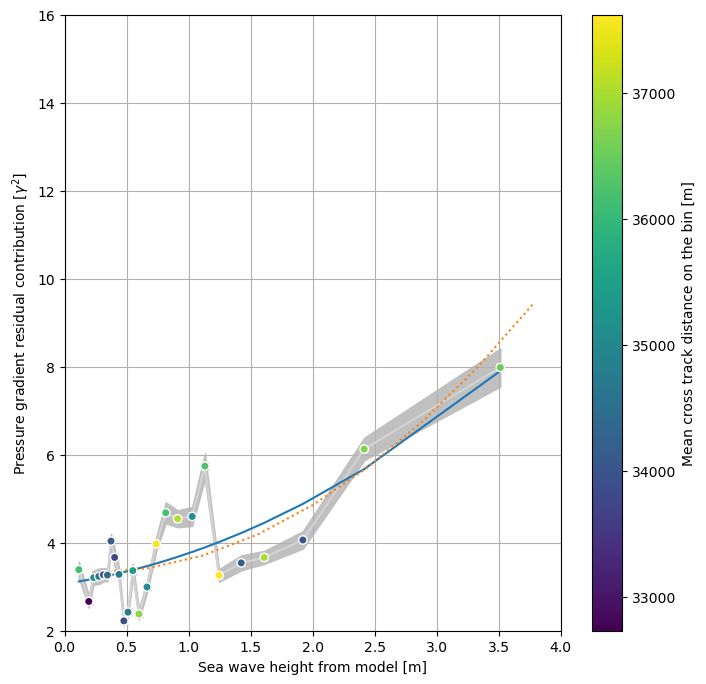

In [38]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dsswh["E_ggd"] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh["ser__E_ggd"] = dsswh.ser__Ex_ggd + dsswh.ser__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker="x", c="lightgrey")
plot_error(dsswh, "swh_model_cut", "E_ggd", ax=ax, suf="ser__")
sc = dsswh.plot.scatter(
    x="swh_model_cut", y="E_ggd", c=dsswh.meanbin_abs_cross_track_distance, zorder=10
)
plt.colorbar(sc, label="Mean cross track distance on the bin [m]")

c1 = dsswh.where(dsswh.swh_model_cut < 2).swh_model_cut
coef1 = np.polyfit(c1, dsswh.E_ggd, 2, w=dsswh.nb_coloc)
ax.plot(c1, coef1[0] * c1**2 + coef1[1] * c1 + coef1[2])
ax.plot(c, coef[0] * c**2 + coef[1] * c + coef[2], ls=":")

ax.grid()
ax.set_ylabel(r"Pressure gradient residual contribution [$\gamma^2$]")
ax.set_xlabel(r"Sea wave height from model [m]")
ax.set_ylim(2, 16)
ax.set_xlim(0, 4)

(6000.0, 7500.0)

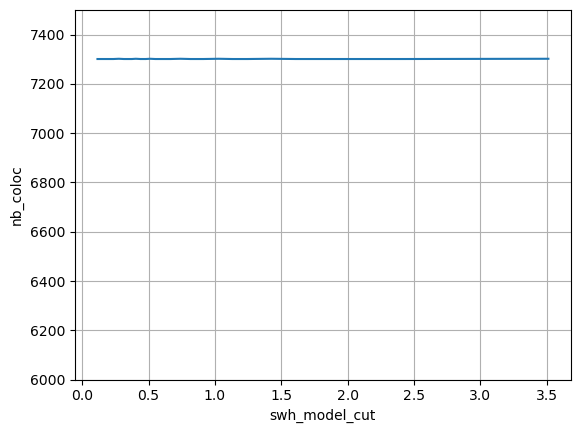

In [32]:
dsswh.nb_coloc.plot()
plt.grid()
plt.ylim(6000, 7500)

Text(0.5, 0, 'Sea wave height from model [m]')

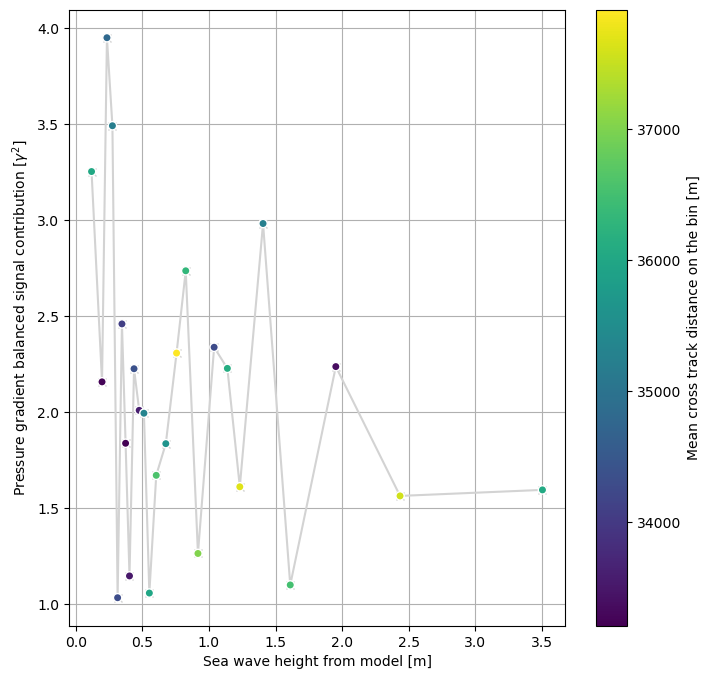

In [132]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dsswh["B_ggd"] = dsswh.Bx_ggd + dsswh.By_ggd
# dsswh['ber__B_ggd'] = dsswh.ber__Bx_ggd + dsswh.ber__By_ggd
dsswh.B_ggd.plot(ax=ax, marker="x", c="lightgrey")
# plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax, suf='ber')
sc = dsswh.plot.scatter(
    x="swh_model_cut", y="B_ggd", c=dsswh.meanbin_abs_cross_track_distance, zorder=10
)
plt.colorbar(sc, label="Mean cross track distance on the bin [m]")


ax.grid()
ax.set_ylabel(r"Pressure gradient balanced signal contribution [$\gamma^2$]")
ax.set_xlabel(r"Sea wave height from model [m]")